NAME: Saurabh Kumar Jha

SECTION: B

ROLL.NO.: 53

CU ID: CU24250005

##LAB SHEET - 06

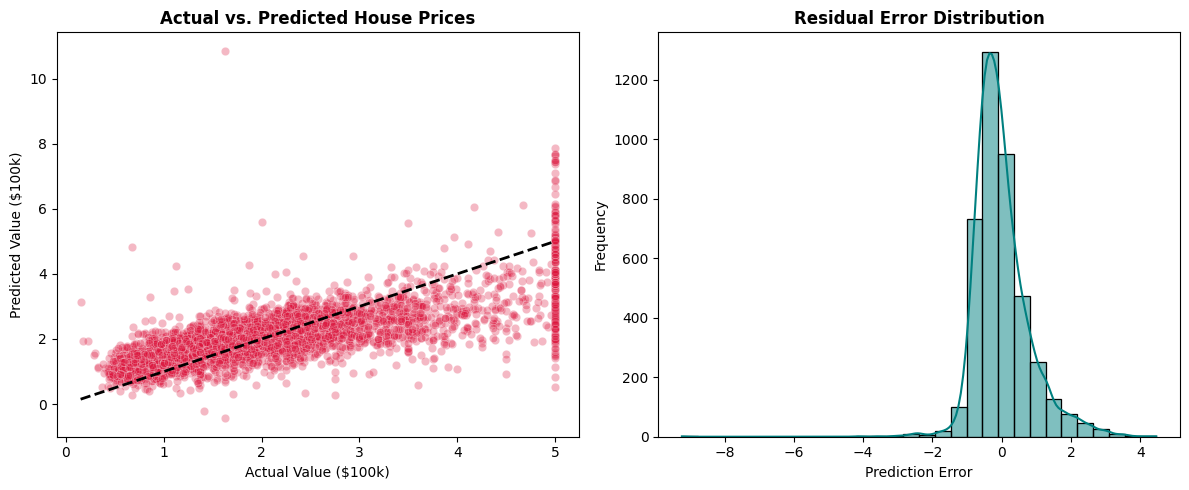

=== Model Performance Metrics ===
Mean Absolute Error (MAE)  : 0.5792
Mean Squared Error (MSE)   : 0.6422
Root Mean Squared Error (RMSE): 0.8014
R² Score                   : 0.5099


=== Regression Coefficients ===
Intercept: -0.5529

   Feature  Coefficient
 AveBedrms     1.115493
    MedInc     0.546161
  HouseAge     0.016788
Population     0.000023
  AveOccup    -0.004618
  AveRooms    -0.223920


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 1 & 2: Load Dataset (California Housing)
raw_data = fetch_california_housing(as_frame=True)
housing_df = raw_data.frame

# Step 3: Preprocessing & Feature Selection
# Target variable: MedHouseVal (House Price in $100,000s)
# Features selected: MedInc (Median Income), HouseAge, AveRooms, AveBedrms, Population, AveOccup
X = housing_df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']]
y = housing_df['MedHouseVal']

# Check and handle missing values
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

# Step 4: Train-Test Split (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Step 5: Model Training
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

# Step 6: Make Predictions
y_pred = regression_model.predict(X_test)

# Step 7: Visualization
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted Prices
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title("Actual vs. Predicted House Prices", fontsize=12, fontweight='bold')
plt.xlabel("Actual Value ($100k)")
plt.ylabel("Predicted Value ($100k)")

# Plot 2: Residual Distribution
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='teal', bins=30)
plt.title("Residual Error Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Step 8: Model Performance Evaluation
mae_metric = mean_absolute_error(y_test, y_pred)
mse_metric = mean_squared_error(y_test, y_pred)
rmse_metric = np.sqrt(mse_metric)
r2_metric = r2_score(y_test, y_pred)

print("=== Model Performance Metrics ===")
print(f"Mean Absolute Error (MAE)  : {mae_metric:.4f}")
print(f"Mean Squared Error (MSE)   : {mse_metric:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_metric:.4f}")
print(f"R² Score                   : {r2_metric:.4f}")
print("\n" + "="*50 + "\n")

# Step 9: Analyze Coefficients
coefficient_summary = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': regression_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("=== Regression Coefficients ===")
print(f"Intercept: {regression_model.intercept_:.4f}\n")
print(coefficient_summary.to_string(index=False))



### Questions and Answers

**1. What is Predictive Analytics, and how is it used in real-world applications?**

* **Definition:** Predictive analytics uses statistical algorithms, historical data, and machine learning models to forecast future events or numeric outcomes.
* **Real-World Applications:** Credit scoring in banking, demand forecasting in retail inventory management, predictive maintenance in industrial manufacturing, and disease risk assessment in healthcare.

**2. Explain the working principle of the Linear Regression algorithm.**

Linear Regression models the relationship between independent features ($X$) and a continuous dependent variable ($y$) by fitting a linear equation to the observed data. It calculates optimal weight coefficients ($\beta$) that minimize the sum of squared differences (Ordinary Least Squares) between actual observations and model predictions:

$$y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n + \epsilon$$

**3. Differentiate between dependent and independent variables with suitable examples.**

* **Independent Variable ($X$):** Predictor inputs controlled or measured to predict outcomes (e.g., house square footage or median local income).
* **Dependent Variable ($y$):** Target outcome being predicted, which depends on changes in independent variables (e.g., market house price).

**4. Why is it necessary to split the dataset into training and testing sets?**

Splitting data evaluates model generalization capability on unseen samples. Training on one subset ($80\%$) while evaluating performance on a separate testing subset ($20\%$) prevents optimistic bias and detects model overfitting.

**5. What is the significance of the $R^2$ Score in regression analysis?**

* **Definition:** The $R^2$ Score (Coefficient of Determination) measures the proportion of total target variable variance explained by independent features in the model.
* **Interpretation:** Values range from $0.0$ to $1.0$. An $R^2 = 0.60$ means $60\%$ of target variance is explained by model features, while $40\%$ remains unexplained residual error.

**6. Differentiate between MAE, MSE, and RMSE. Which metric is more sensitive to large prediction errors?**

* **Mean Absolute Error (MAE):** Average magnitude of absolute error bounds without considering error sign direction.
* **Mean Squared Error (MSE):** Average squared difference between predictions and actual targets.
* **Root Mean Squared Error (RMSE):** Square root of MSE, returning error units back to original target scales.
* **Sensitivity:** **MSE** and **RMSE** square individual error values, making them significantly more sensitive to large outliers compared to MAE.

**7. What assumptions should be satisfied before applying Linear Regression?**

* **Linearity:** Linear relationship between independent features and target values.
* **Independence:** Independent residual errors (no autocorrelation).
* **Homoscedasticity:** Constant error variance across predicted target values.
* **Normality:** Residual errors follow an approximately normal distribution.
* **No Multicollinearity:** Independent features should not be highly correlated with one another.

**8. How can overfitting and underfitting affect the performance of a regression model?**

* **Underfitting:** The model is overly simplistic, failing to capture underlying patterns in both training and testing datasets (low training accuracy, low test accuracy).
* **Overfitting:** The model memorizes training noise and outliers instead of true underlying distributions, failing on new inputs (high training accuracy, low test accuracy).

**9. Mention any three real-world applications of Linear Regression in business or industry.**

* **Sales Forecasting:** Estimating quarterly product revenue based on advertising expenditure across marketing channels.
* **Real Estate Valuation:** Predicting market property values based on structural characteristics and location metrics.
* **Risk Management:** Estimating financial insurance claim costs based on customer policy metrics.

**10. How can feature selection improve the accuracy and interpretability of a predictive model?**

Removing redundant or noisy features reduces model complexity, mitigates multicollinearity, prevents overfitting, lowers computational footprint, and clarifies domain interpretation of feature coefficients.

